Proyecto: Aprendizaje No Supervisado

Alumnos:
Ceron Samperio Lizeth Montserrat
Higuera Pineda Angel Abraham
Sanchez Rolon Pedro

Instrucciones

Aplicar y comparar al menos 5 variantes de técnicas de aprendizaje no supervisado realizando un análisis de desempeño mediante métricas como calidad de cluster.

In [1]:
##Para insalar las librerias se utiliza el siguiente comando:
#pip install numpy pandas matplotlib scikit-learn scikit-learn-extra
%pip install "numpy<2.0" --force-reinstall
#%pip install setuptools  # esto restaura distutils
%pip install openpyxl

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#%pip install --upgrade --force-reinstall scikit-learn-extra

In [3]:
# Librerías estándar
import os
import glob
import tarfile
import urllib.request

# Manejo de datos y matemáticas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Procesamiento de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Reducción de dimensionalidad
from sklearn.decomposition import TruncatedSVD

# Clustering
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn_extra.cluster import KMedoids

# Métricas de evaluación
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Preprocesamiento
from sklearn.preprocessing import normalize

In [4]:
import pandas as pd

#1. Inicializando la lista global que almacenará el registro de todos los modelos y sus métricas evaluadas
historial_resultados = []

def guardar_resultado(modelo_nombre, parametros, silhouette, davies, extra_metric_name="", extra_metric_val=""):
    """Guarda una fila de resultados en el historial."""
    #Agrega un diccionario con las métricas obtenidas al historial, redondeando a 4 decimales para mayor legibilidad y manejando valores nulos con "N/A" para evitar discrepancias en la tabla
    historial_resultados.append({
        "Técnica / Algoritmo": modelo_nombre,
        "Parámetros": parametros,
        "Silhouette": round(silhouette, 4) if silhouette is not None else "N/A",
        "Davies-Bouldin": round(davies, 4) if davies is not None else "N/A",
        extra_metric_name: round(extra_metric_val, 2) if extra_metric_val != "" else "N/A"
    })

#2. FUNCIÓN PARA MOSTRAR LA TABLA DE RESULTADOS
def mostrar_tabla_resultados():
    """Imprime el historial de resultados en formato Markdown."""
    print("\n" + "="*80)
    print("TABLA COMPARATIVA DE RESULTADOS FINALES")
    print("="*80)
    
    #Convierte la lista de diccionarios en un DataFrame de pandas para facilitar su manipulación y visualización tabular estructurada
    df_resultados = pd.DataFrame(historial_resultados)
    
    #¡¡IMPORTANTE!! Convertimos todo a texto y reemplazamos los valores 'nan' por cadenas vacías para que la tabla final se vea limpia y profesional
    df_resultados = df_resultados.astype(str).replace('nan', '')
    
    #Imprime el DataFrame en formato Markdown omitiendo el índice numérico por defecto, lo que es ideal para pegar en reportes o leer en cuadernos de Jupyter
    print(df_resultados.to_markdown(index=False))
    
    print("="*80 + "\n")

In [5]:
#1. FUNCIÓN PARA OBTENER Y PREPARAR EL DATASET IMDB
def obtener_dataset_imdb(url, carpeta_destino):
    #Verificamos si la carpeta destino existe, si no, la creamos automáticamente para evitar errores de "ruta no encontrada" al guardar el archivo
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
        
    archivo_gz = os.path.join(carpeta_destino, "aclImdb_v1.tar.gz")
    ruta_extraccion = os.path.join(carpeta_destino, "aclImdb")

    #2. DESCARGA CONDICIONAL
    #Solo descargamos el archivo comprimido si no existe previamente en la ruta, esto es vital para ahorrar tiempo de ejecución y no gastar ancho de banda innecesario
    if not os.path.exists(archivo_gz):
        print(f"Descargando dataset desde: {url}...")
        urllib.request.urlretrieve(url, archivo_gz)
    
    #3. EXTRACCIÓN DE LOS DATOS
    #Descomprimimos el archivo tar.gz asegurándonos de no repetir este pesado proceso si la carpeta de extracción ya está presente
    if not os.path.exists(ruta_extraccion):
        print("Extrayendo archivos (esto puede tardar un momento)...")
        with tarfile.open(archivo_gz, "r:gz") as tar:
            tar.extractall(path=carpeta_destino)
            
    return ruta_extraccion

#4. FUNCIÓN PARA CARGAR LOS TEXTOS EN MEMORIA
def load_imdb_data(base_path, sample_size=None):
    texts = []
    
    #Leemos las reseñas de todas las carpetas sin importar su origen para tener un corpus de texto robusto y variado
    for folder in ['pos', 'neg', 'unsup']: 
        #Buscamos recursivamente todos los archivos .txt dentro de las subcarpetas de entrenamiento correspondientes usando comodines
        pattern = os.path.join(base_path, '**', 'train', folder, '*.txt')
        files = glob.glob(pattern, recursive=True)

        #Si se especificó un límite por carpeta (sample_size), recortamos la lista de archivos para hacer pruebas rápidas y evitar saturar la memoria RAM
        if sample_size:
            files = files[:sample_size]

        for file_path in files:
            #Abrimos cada archivo forzando explícitamente la codificación UTF-8 para evitar que el programa se rompa al encontrar caracteres especiales
            with open(file_path, encoding='utf-8') as f:
                texts.append(f.read())
                
    return texts

In [6]:
#1. DEFINICIÓN DE RUTAS Y DESCARGA
url_stanford = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
#Llamamos a nuestra función previamente creada para asegurar que el dataset esté descargado y listo en la carpeta local "./IMDB_Data" antes de proceder
dataset_path = obtener_dataset_imdb(url_stanford, "./IMDB_Data")

print("\n[FASE 1] Cargando reseñas de forma no supervisada...")
#2. CARGA Y PREPARACIÓN DE DATOS
reviews = load_imdb_data(dataset_path)
#Convertimos la lista plana de reseñas en un DataFrame de pandas para facilitar las operaciones estructuradas de muestreo y extracción que vienen a continuación
df = pd.DataFrame({'review': reviews})

#¡¡IMPORTANTE!! Reducimos drásticamente el dataset a 3000 muestras aleatorias (fijando el random_state=42 para garantizar la reproducibilidad de las pruebas). 
#Esto es un compromiso estrictamente necesario para equilibrar los tiempos de ejecución, permitiendo comparar algoritmos muy pesados (como Spectral/KMedoids) con los más rápidos (como KMeans/GMM) sin que el equipo colapse.
df = df.sample(3000, random_state=42).reset_index(drop=True)

print("[FASE 2] Vectorizando texto (TF-IDF)...")
#3. VECTORIZACIÓN CON TF-IDF
#Usamos TF-IDF limitando a las 3000 características principales y excluyendo palabras comunes en inglés (stop_words='english') para eliminar el ruido. El rango de n-gramas (1,2) permite capturar palabras individuales y pares clave que aportan contexto.
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1,2))
X = vectorizer.fit_transform(df['review'])

#Aplicamos una normalización a la matriz dispersa resultante para asegurar que la longitud variante de los documentos (reseñas largas vs cortas) no sesgue a los algoritmos de clustering que dependen del cálculo de distancias
X = normalize(X)

#4. EXPORTACIÓN DEL VOCABULARIO (Módulo Extra del código 2)
#Extraemos el nombre exacto de las características (palabras) y sumamos sus pesos en toda la matriz (axis=0) para entender matemáticamente qué términos dominaron el corpus
nombres_palabras = vectorizer.get_feature_names_out()
pesos = np.asarray(X.sum(axis=0)).flatten()

#Guardamos este análisis en un archivo Excel, ordenado de mayor a menor importancia, lo que nos servirá como un reporte tangible de las palabras más representativas según el modelo
df_vocabulario = pd.DataFrame({'Palabra': nombres_palabras, 'Importancia_TFIDF': pesos})
df_vocabulario = df_vocabulario.sort_values(by='Importancia_TFIDF', ascending=False)
df_vocabulario.to_excel("vocabulario_imdb.xlsx", index=False)
print("-> Archivo 'vocabulario_imdb.xlsx' creado con éxito.")

print("[FASE 3] Reduciendo dimensiones (SVD)...")
#5. REDUCCIÓN DE DIMENSIONALIDAD (SVD)
#Reducimos la pesada matriz TF-IDF de 3000 dimensiones a solo 100 componentes principales. Esto acelera dramáticamente el entrenamiento de los modelos de agrupamiento al sintetizar la información y eliminar correlaciones espurias.
svd = TruncatedSVD(n_components=100)
X_reduced = svd.fit_transform(X)

#Creamos una segunda versión hiper-reducida de solo 2 componentes (ejes X e Y), la cual usaremos estrictamente para poder graficar y visualizar los clústeres en un plano cartesiano 2D más adelante
svd_2d = TruncatedSVD(n_components=2)
X_2d = svd_2d.fit_transform(X)


[FASE 1] Cargando reseñas de forma no supervisada...
[FASE 2] Vectorizando texto (TF-IDF)...
-> Archivo 'vocabulario_imdb.xlsx' creado con éxito.
[FASE 3] Reduciendo dimensiones (SVD)...



[MODELO 1] Ejecutando Spectral Clustering...


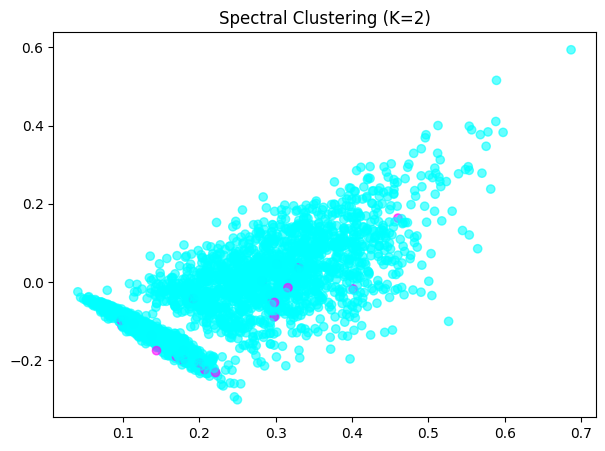

In [7]:
#--- A) SPECTRAL CLUSTERING ---
print("\n[MODELO 1] Ejecutando Spectral Clustering...")

#1. CONFIGURACIÓN DEL MODELO
#Se configura el Spectral Clustering buscando 2 agrupaciones principales (asumiendo reseñas positivas y negativas). Usamos 'nearest_neighbors' con 10 vecinos en lugar del kernel RBF por defecto, ya que construir la matriz de afinidad mediante vecinos más cercanos suele ser más efectivo y manejable para datos dispersos provenientes de texto.
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=10)

#2. ENTRENAMIENTO Y ASIGNACIÓN DE ETIQUETAS
#Alimentamos al modelo con la matriz reducida a 100 dimensiones (X_reduced) para realizar el cálculo. Esto es vital porque Spectral Clustering es computacionalmente muy pesado y colapsaría si le pasamos las 3000 dimensiones originales.
labels_spectral = spectral.fit_predict(X_reduced)

#3. CÁLCULO DE MÉTRICAS INTERNAS
#Evaluamos la calidad matemática de los grupos formados. Silhouette mide la cohesión y separación (valores más cercanos a 1 son mejores), mientras que Davies-Bouldin mide la similitud entre clústeres (valores más bajos indican una mejor separación).
score_spec = silhouette_score(X_reduced, labels_spectral)
db_spec = davies_bouldin_score(X_reduced, labels_spectral)

#Registramos las métricas obtenidas en nuestra lista global para que aparezcan en la tabla comparativa final.
guardar_resultado("Spectral Clustering", "k=2, aff='nearest_neighbors'", score_spec, db_spec)

#4. VISUALIZACIÓN GRÁFICA EN 2D
#¡¡IMPORTANTE!! A diferencia del entrenamiento, aquí usamos estrictamente X_2d (la matriz hiper-reducida de 2 componentes) porque es la única forma de representar los datos visualmente en un plano cartesiano convencional.
plt.figure(figsize=(7, 5))

#Pintamos los puntos según la etiqueta asignada por el modelo (c=labels_spectral). Se aplica alpha=0.6 para darle transparencia a los puntos y poder visualizar correctamente la densidad en las áreas donde las reseñas se sobreponen.
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_spectral, cmap='cool', alpha=0.6)
plt.title('Spectral Clustering (K=2)')
plt.show()


[MODELO 2] Ejecutando K-Medoids...


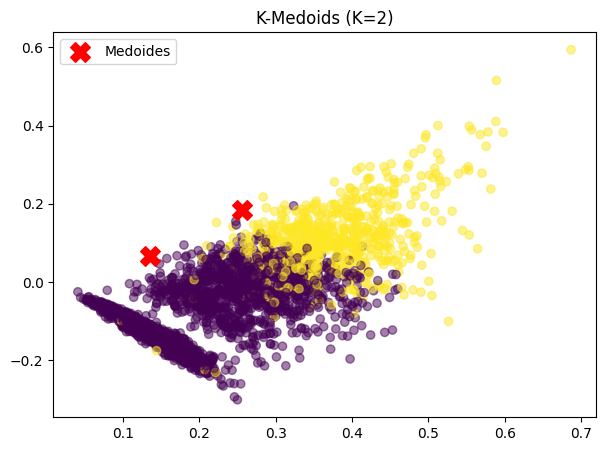

In [8]:
# --- B) K-MEDOIDS ---
print("\n[MODELO 2] Ejecutando K-Medoids...")

#1. CONFIGURACIÓN DEL ALGORITMO K-MEDOIDS
#A diferencia de KMeans que usa el promedio (centroide), K-Medoids utiliza puntos reales del dataset (medoides) como centros, lo que lo hace mucho más robusto ante valores atípicos (outliers). 
#Usamos el método 'pam' (Partitioning Around Medoids) y una inicialización heurística para mejorar la convergencia inicial del algoritmo en este conjunto de reseñas.
kmedoids = KMedoids(n_clusters=2, metric='euclidean', method='pam', init='heuristic', random_state=42)

#2. ENTRENAMIENTO Y PREDICCIÓN
#Ejecutamos el proceso de agrupamiento sobre la matriz reducida de 100 componentes (X_reduced). K-Medoids asigna cada reseña al grupo cuyo medoide sea el más cercano según la métrica euclidiana.
labels_kmed = kmedoids.fit_predict(X_reduced)

#3. EVALUACIÓN DE DESEMPEÑO
#Calculamos Silhouette y Davies-Bouldin para comparar la calidad de este agrupamiento frente a los otros modelos.
score_kmed = silhouette_score(X_reduced, labels_kmed)
db_kmed = davies_bouldin_score(X_reduced, labels_kmed)

#¡¡INTERESANTE!! En este modelo también guardamos la "Inercia" como métrica extra, que representa la suma de las distancias de cada punto a su medoide correspondiente; entre más baja, mayor cohesión interna.
guardar_resultado("K-Medoids", "k=2, metric='euclidean'", score_kmed, db_kmed, "Inercia", kmedoids.inertia_)

#4. VISUALIZACIÓN DE CLÚSTERES Y MEDOIDES
plt.figure(figsize=(7, 5))

#Graficamos los puntos usando la reducción a 2 dimensiones (X_2d) para que sean visibles, asignando colores según las etiquetas predichas por el modelo.
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmed, cmap='viridis', alpha=0.5)

#¡¡CRÍTICO!! Para mostrar los centros reales del modelo, extraemos los índices de los medoides identificados y localizamos sus coordenadas exactas en el espacio 2D.
medoides_coords = X_2d[kmedoids.medoid_indices_] 

#Dibujamos los medoides como una 'X' roja de gran tamaño (s=200) para destacar visualmente el "corazón" o representante real de cada clúster de reseñas.
plt.scatter(medoides_coords[:, 0], medoides_coords[:, 1], c='red', marker='X', s=200, label='Medoides')

plt.title('K-Medoids (K=2)')
plt.legend()
plt.show()


[MODELO 3] Buscando mejor K para K-Means...


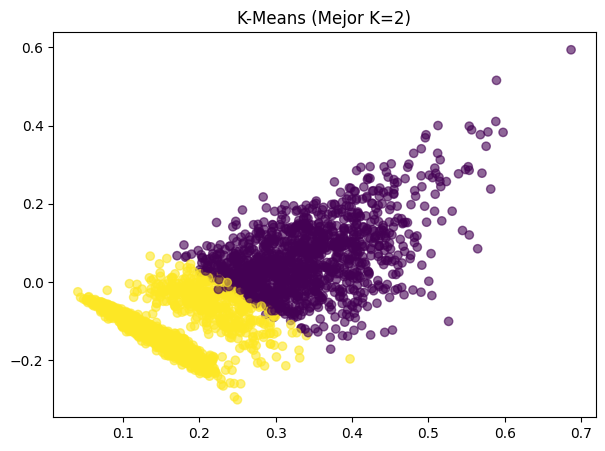

In [9]:
#--- C) K-MEANS (Búsqueda Iterativa) ---
print("\n[MODELO 3] Buscando mejor K para K-Means...")

#1. INICIALIZACIÓN DE VARIABLES PARA LA BÚSQUEDA DEL MEJOR MODELO
#Establecemos un puntaje inicial de -1 para asegurar que cualquier resultado del coeficiente de Silhouette sea mayor y así poder capturar la mejor configuración en la primera iteración.
best_score_km = -1

#2. BÚSQUEDA ITERATIVA (ELBOW METHOD / SILHOUETTE OPTIMIZATION)
#Ejecutamos un ciclo para probar diferentes valores de K (desde 2 hasta 5 grupos). Esto nos permite determinar de forma empírica cuál es el número óptimo de clústeres para nuestro dataset de reseñas de IMDB.
for k in range(2, 6):
    #Configuramos KMeans con n_init=10 para que el algoritmo corra 10 veces con diferentes semillas iniciales, seleccionando la mejor; esto evita caer en óptimos locales deficientes.
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    #Entrenamos usando la matriz reducida de 100 dimensiones (X_reduced) para optimizar la velocidad de cálculo sin perder la esencia de la información textual.
    labels = km.fit_predict(X_reduced)
    
    #Calculamos las métricas para cada K probado para tener un sustento matemático antes de elegir el modelo definitivo.
    score = silhouette_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)
    
    #Registramos cada intento en el historial para que en la tabla final podamos ver cómo evolucionan las métricas al aumentar el número de grupos.
    guardar_resultado("K-Means", f"k={k}, n_init=10", score, db, "Inercia", km.inertia_)
    
    #3. SELECCIÓN DEL MEJOR K
    #¡¡CRÍTICO!! Comparamos el Silhouette actual con el mejor registrado. Si es mayor, guardamos esta configuración como la ganadora para usarla en la visualización final.
    if score > best_score_km:
        best_score_km = score
        best_k_km = k
        best_labels_km = labels

#4. VISUALIZACIÓN DEL MEJOR RESULTADO
plt.figure(figsize=(7, 5))

#Pintamos los puntos en el espacio 2D (X_2d) usando las etiquetas del mejor modelo encontrado durante la iteración anterior.
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels_km, cmap='viridis', alpha=0.6)

#Mostramos dinámicamente el valor de K que obtuvo el mejor desempeño en el título del gráfico.
plt.title(f'K-Means (Mejor K={best_k_km})')
plt.show()


[MODELO 4] Buscando mejor eps para DBSCAN...


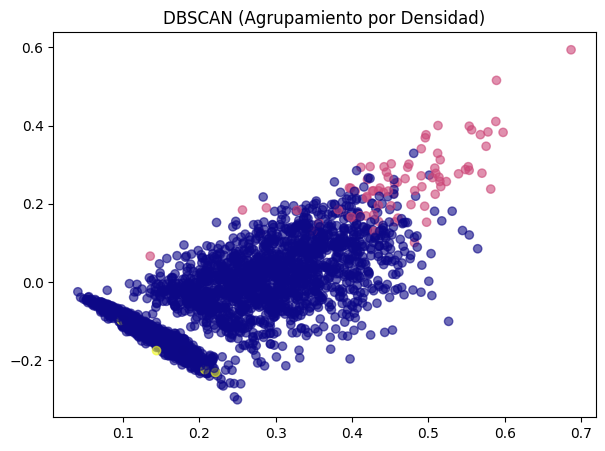

In [10]:
#--- D) DBSCAN ---
print("\n[MODELO 4] Buscando mejor eps para DBSCAN...")

#1. INICIALIZACIÓN DE VARIABLES PARA LA OPTIMIZACIÓN POR DENSIDAD
#DBSCAN es extremadamente sensible al radio de búsqueda (épsilon), por lo que definimos estas variables para capturar la configuración que logre el mejor balance en la estructura de los clústeres.
best_score_dbscan = -1
best_labels_dbscan = None

#2. BÚSQUEDA ITERATIVA DEL MEJOR EPSILON
#Probamos diferentes valores para encontrar la densidad adecuada. ¡¡IMPORTANTE!! Usamos la métrica 'cosine' porque en NLP es mucho más efectiva que la euclidiana para medir la similitud entre vectores de texto, enfocándose en la dirección del vector y no en su magnitud.
for eps in [0.05, 0.1, 0.15, 0.2]:
    #Configuramos min_samples=5 para asegurar que un grupo solo sea clúster si tiene una densidad mínima de puntos, lo que ayuda a filtrar el ruido pequeño.
    db = DBSCAN(eps=eps, min_samples=5, metric='cosine')
    labels = db.fit_predict(X_reduced)
    
    #¡¡ATENCIÓN!! Calculamos la cantidad de clústeres encontrados restando 1 si existe la etiqueta -1, la cual DBSCAN utiliza para marcar puntos que considera ruido o "outliers".
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    #3. EVALUACIÓN Y REGISTRO DE RESULTADOS
    #Solo procesamos el modelo si el algoritmo logró identificar al menos 2 grupos distintos, de lo contrario las métricas de validación como Silhouette no se pueden calcular.
    if n_clusters > 1:
        score = silhouette_score(X_reduced, labels)
        db_score = davies_bouldin_score(X_reduced, labels)
        
        #Almacenamos los resultados en el historial incluyendo el número de clústeres como métrica extra para observar cómo afecta el radio 'eps' a la fragmentación de las reseñas.
        guardar_resultado("DBSCAN", f"eps={eps}, metric='cosine'", score, db_score, "Clusters", n_clusters)
        
        #¡¡CRÍTICO!! Si este Silhouette es el más alto hasta ahora, actualizamos las etiquetas ganadoras para la visualización final del agrupamiento.
        if score > best_score_dbscan:
            best_score_dbscan = score
            best_labels_dbscan = labels

#4. GRÁFICO DBSCAN (Si encontró clusters válidos)
#Solo generamos la visualización si el proceso de búsqueda encontró clústeres reales, evitando errores si todos los puntos fueron clasificados como ruido.
if best_labels_dbscan is not None:
    plt.figure(figsize=(7, 5))
    
    #Graficamos usando la reducción a 2 dimensiones (X_2d) con el mapa de colores 'plasma', donde los puntos de color representan los clústeres densos de reseñas identificados.
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels_dbscan, cmap='plasma', alpha=0.6)
    plt.title('DBSCAN (Agrupamiento por Densidad)')
    plt.show()


[MODELO 5] Buscando mejor modelo GMM...


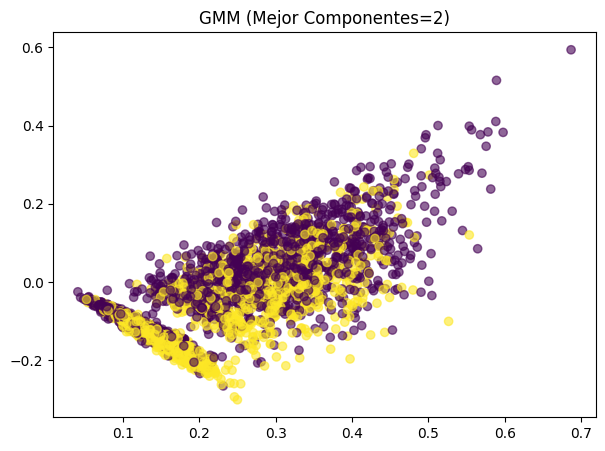

In [11]:
#--- E) GAUSSIAN MIXTURE MODELS (GMM) ---
print("\n[MODELO 5] Buscando mejor modelo GMM...")

#1. INICIALIZACIÓN PARA LA BÚSQUEDA DE COMPONENTES
best_score_gmm = -1

#2. OPTIMIZACIÓN PROBABILÍSTICA (BÚSQUEDA DE K)
#A diferencia de KMeans, GMM es un modelo probabilístico que asume que los datos vienen de una mezcla de distribuciones gaussianas. Iteramos de 2 a 5 componentes para encontrar la estructura que mejor represente la densidad de las reseñas.
for k in range(2, 6):
    #¡¡IMPORTANTE!! Usamos covariance_type='diag' para que el modelo sea más eficiente en términos de memoria al procesar texto, asumiendo que las variables son independientes dentro de cada clúster. 
    #Configuramos n_init=5 para realizar múltiples reinicios y evitar quedar atrapados en soluciones subóptimas de verosimilitud.
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42, n_init=5)
    
    #Entrenamos el modelo con la matriz reducida (X_reduced). GMM nos da una pertenencia "suave" (probabilidades), pero fit_predict nos devuelve la etiqueta del grupo más probable para cada reseña.
    labels = gmm.fit_predict(X_reduced) 
    
    #Calculamos las métricas de cohesión (Silhouette) y separación (Davies-Bouldin) para mantener la consistencia con los modelos anteriores.
    score = silhouette_score(X_reduced, labels)
    db_score = davies_bouldin_score(X_reduced, labels)
    
    #¡¡INTERESANTE!! Obtenemos el BIC (Bayesian Information Criterion). Esta es la métrica reina para modelos de mezcla, ya que penaliza modelos demasiado complejos; un BIC más bajo indica un mejor equilibrio entre ajuste y simplicidad.
    bic_score = gmm.bic(X_reduced)
    
    #Registramos todos los parámetros y métricas, incluyendo el BIC como valor extra, para el análisis comparativo final.
    guardar_resultado("GMM", f"k={k}, cov='diag'", score, db_score, "BIC", bic_score)

    #3. SELECCIÓN DEL MEJOR MODELO PROBABILÍSTICO
    #Si el Silhouette mejora, actualizamos nuestras variables ganadoras para la fase de visualización.
    if score > best_score_gmm:
        best_score_gmm = score
        best_k_gmm = k
        best_labels_gmm = labels

#4. VISUALIZACIÓN DE LA DISTRIBUCIÓN DE COMPONENTES
plt.figure(figsize=(7, 5))

#Dibujamos los puntos en el espacio 2D (X_2d) coloreados según las etiquetas del mejor modelo GMM encontrado en la fase de optimización.
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels_gmm, cmap='viridis', alpha=0.6)

plt.title(f'GMM (Mejor Componentes={best_k_gmm})')
plt.show()

In [ ]:
mostrar_tabla_resultados()
#LOS RESULTADOS FINALES PUEDEN CAMBIAR LEVEMENTE EN CADA EJECUCIÓN DEBIDO A LA ALEATORIEDAD INHERENTE EN LOS MODELOS Y LA REDUCCIÓN DE DIMENSIONALIDAD, PERO DEBERÍAN MANTENERSE DENTRO DE UN RANGO SIMILAR SI SE EJECUTA VARIAS VECES.
#ADEMÁS LOS RESULTADOS ANOTADOS EN EL DOCUMENTOS, FUERON REALIZADOS DE MANERA INDIVIDUAL
#AL UNIRLOS TODOS, SE TUVIERON QUE REESTRUCTURAR ALGUNAS FUNCIONES Y LLAMADOS A LA DESCARGA DEL DATASET


TABLA COMPARATIVA DE RESULTADOS FINALES
| Técnica / Algoritmo   | Parámetros                   |   Silhouette |   Davies-Bouldin |     |   Inercia |   Clusters |           BIC |
|:----------------------|:-----------------------------|-------------:|-----------------:|:----|----------:|-----------:|--------------:|
| Spectral Clustering   | k=2, aff='nearest_neighbors' |       0.1366 |           1.8325 | N/A |    nan    |        nan | nan           |
| K-Medoids             | k=2, metric='euclidean'      |       0.065  |           3.1863 | nan |   1395.41 |        nan | nan           |
| K-Means               | k=2, n_init=10               |       0.0714 |           3.3747 | nan |    557.87 |        nan | nan           |
| K-Means               | k=3, n_init=10               |       0.0531 |           4.617  | nan |    547.38 |        nan | nan           |
| K-Means               | k=4, n_init=10               |       0.0272 |           4.7966 | nan |    538.42 |        nan | nan      